In [1]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)
path = "/content/drive/MyDrive/projet/"

Mounted at /content/drive/


In [2]:

import json

with open('/content/drive/MyDrive/projet/test_videodatainfo/test_videodatainfo.json', 'r') as file:
    data_test = json.load(file)

for key, item in data_test.items():
    print(key)

info
videos
sentences


In [3]:
# on doit fusionner les deux listes 'sentences' et 'videos' sur la clé 'video_id'

# données de Test

sentences = data_test['sentences']
videos = data_test['videos']

test = []

# dictionnaire selon identifiant de la video
dict_videos = {d['video_id']: d for d in videos}

for d1 in sentences:
    vid = d1['video_id']
    fusion_donnees = d1.copy()
    # Si on trouve le même video_id dans la 2e liste, on ajoute ses clés
    if vid in dict_videos:
        fusion_donnees.update(dict_videos[vid])
    # Ajout du résultat à la liste finale
    test.append(fusion_donnees)

In [4]:

with open('/content/drive/MyDrive/projet/train_val_annotation/train_val_videodatainfo.json', 'r') as file:
    data_train_val = json.load(file)

In [5]:
# fusion des données de Train_val

sentences = data_train_val['sentences']
videos = data_train_val['videos']

train_val = []

dict_videos = {d['video_id']: d for d in videos}

for d1 in sentences:
    vid = d1['video_id']
    fusion_donnees = d1.copy()
    if vid in dict_videos:
        fusion_donnees.update(dict_videos[vid])
    train_val.append(fusion_donnees)

In [7]:
print(f"taille de train_val, {len(train_val)}, taille ddu test {len(test)}")

taille de train_val, 140200, taille ddu test 59800


Séparation en train, val

In [ ]:
# Séparation selon la clé 'split'
train = [item for item in train_val if item.get('split') == 'train']
val = [item for item in train_val if item.get('split') != 'train']

Stat descriptives sur les données d'entrainement

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = train

# Conversion en DataFrame pandas
df = pd.DataFrame(data)

df.head()

,caption,video_id,sen_id,category,url,start time,end time,split,id
0,a cartoon animals runs through an ice cave in ...,video2960,0,2,https://www.youtube.com/watch?v=2nQWv233XrM,318.16,330.48,train,2960
1,a cartoon character runs around inside of a vi...,video2960,1,2,https://www.youtube.com/watch?v=2nQWv233XrM,318.16,330.48,train,2960
2,a character is running in the snow,video2960,2,2,https://www.youtube.com/watch?v=2nQWv233XrM,318.16,330.48,train,2960
3,a person plays a video game centered around ic...,video2960,3,2,https://www.youtube.com/watch?v=2nQWv233XrM,318.16,330.48,train,2960
4,a person plays online and records themselves,video2960,4,2,https://www.youtube.com/watch?v=2nQWv233XrM,318.16,330.48,train,2960


In [10]:
# Nombre total de captions
nb_captions = len(df)

# Nombre total de vidéos
nb_videos = df['video_id'].nunique()

# Nombre de catégories
nb_categories = df['category'].nunique()

print(f"Nombre total de captions : {nb_captions}")
print(f"Nombre total de vidéos : {nb_videos}")
print(f"Nombre de catégories : {nb_categories}")


Nombre total de captions : 130260
Nombre total de vidéos : 6513
Nombre de catégories : 20


In [11]:
captions_par_video = df.groupby('video_id').size()
print(f"Nombre moyen de captions par vidéo : {captions_par_video.mean()}")
print(f"Min: {captions_par_video.min()}, Max: {captions_par_video.max()}")


Nombre moyen de captions par vidéo : 20.0
Min: 20, Max: 20


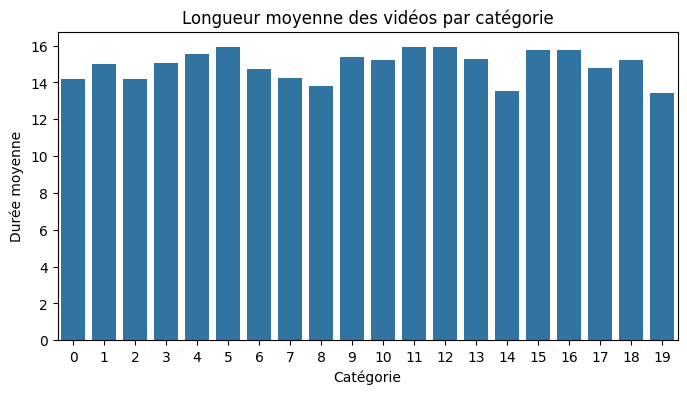

In [12]:
df['video_length'] = df['end time'] - df['start time']

mean_length_video = df.groupby('category')['video_length'].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=mean_length_video.index, y=mean_length_video.values)
plt.title("Longueur moyenne des vidéos par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Durée moyenne")
plt.show()


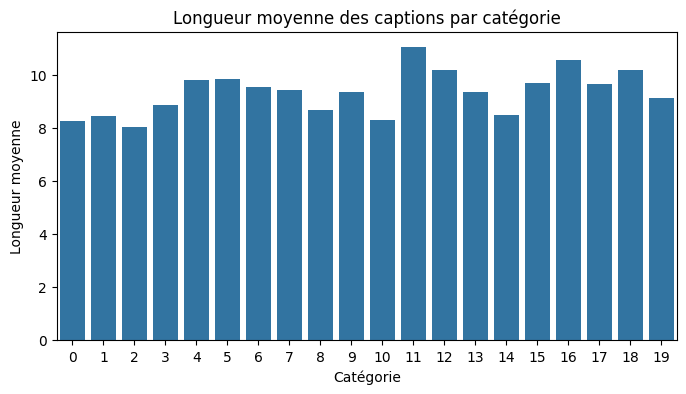

In [13]:
df['caption_length'] = df['caption'].apply(lambda x: len(x.split()))

mean_length_caption = df.groupby('category')['caption_length'].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=mean_length_caption.index, y=mean_length_caption.values)
plt.title("Longueur moyenne des captions par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Longueur moyenne")
plt.show()


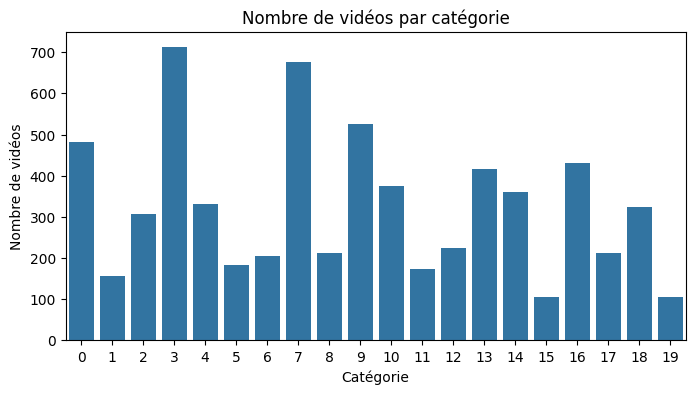

In [14]:
videos_par_category = df.groupby('category')['video_id'].nunique()

plt.figure(figsize=(8,4))
sns.barplot(x=videos_par_category.index, y=videos_par_category.values)
plt.title("Nombre de vidéos par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de vidéos")
plt.show()

### Preparation des données

In [ ]:
from torch.utils.data import Dataset, DataLoader

class VideoCaptionDataset(Dataset):
    def __init__(self, data):
        self.captions = [item['caption'] for item in data]
        self.labels = [item['category'] for item in data]

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        return {
            'text': self.captions[idx],
            'label': self.labels[idx]
        }

train_dataset = VideoCaptionDataset(train)
val_dataset = VideoCaptionDataset(val)
test_dataset = VideoCaptionDataset(test)

# **1er modèle**

### Tokenization

In [ ]:
from transformers import AutoTokenizer, AutoModel

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def collate_fn(batch):
    texts = [x['text'] for x in batch]
    labels = [x['label'] for x in batch]
    encodings = tokenizer(texts, truncation=True, padding=True, return_tensors="pt")
    encodings['labels'] = torch.tensor(labels)
    return encodings

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# les labels

import torch

# Exemple de labels_map
labels_map = {
    0: "music",
    1: "people",
    2: "gaming",
    3: "sports/actions",
    4: "news/events/politics",
    5: "education",
    6: "tv shows",
    7: "movie/comedy",
    8: "animation",
    9: "vehicles/autos",
    10: "howto",
    11: "travel",
    12: "science/technology",
    13: "animals/pets",
    14: "kids/family",
    15: "documentary",
    16: "food/drink",
    17: "cooking",
    18: "beauty/fashion",
    19: "advertisement"
}


Modele

In [ ]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, hidden_dim=512, output_dim=20, n_layers=4, dropout=0.5):
        super().__init__()
        self.bert = AutoModel.from_pretrained("distilbert-base-uncased")

        # Geler DistilBERT pour n'entraîner que la dernière couche
        for param in self.bert.parameters():
            param.requires_grad = False

        self.lstm = nn.LSTM(768, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout)

        self.fc1 = nn.Linear(hidden_dim, 512)
        self.fc2 = nn.Linear(512, 700)
        self.fc3 = nn.Linear(700, 512)
        self.fc4 = nn.Linear(512, output_dim)

        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.batch_norm = nn.BatchNorm1d(hidden_dim)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        embedded = outputs.last_hidden_state
        _, (hidden, _) = self.lstm(embedded)  # hidden[-1] : dernière couche du lstm
        hidden = self.batch_norm(hidden[-1])

        x = self.dropout(self.relu(self.fc1(hidden)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.dropout(self.relu(self.fc3(x)))
        x = self.fc4(x)
        return x

Réequilibre des classes

Boucle d'entrainement

In [ ]:
import torch.optim as optim
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMClassifier(hidden_dim=512, output_dim=20, n_layers=2, dropout=0.5
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=2e-4)

# Scheduler adaptatif basé sur la validation
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

save_path = "best_model.pt"

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

best_val_loss = 1000

liste_train_acc = []
liste_train_loss = []
liste_val_acc = []
liste_val_loss = []

all_preds = []
all_labels = []

for epoch in range(50):
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss /= len(train_loader)
    train_accuracy = correct_train / total_train

    # Validation
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids, attention_mask)
            loss = F.cross_entropy(outputs, labels)

            preds = outputs.argmax(dim=1)
            correct_val += (preds == labels).sum().item()

            val_loss += loss.item()
            total_val += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = correct_val / total_val

    print(f"Epoch {epoch+1} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
    liste_train_acc.append(train_accuracy)
    liste_train_loss.append(train_loss)
    liste_val_acc.append(val_accuracy)
    liste_val_loss.append(val_loss)

    # Sauvegarde du meilleur modèle
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print("=> Best model saved")

    # Scheduler
    scheduler.step(val_loss)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Epoch 1 | Train Loss: 2.0126, Train Acc: 0.4294 | Val Loss: 1.7315, Val Acc: 0.5057
=> Best model saved
Epoch 2 | Train Loss: 1.7616, Train Acc: 0.5075 | Val Loss: 1.6562, Val Acc: 0.5278
=> Best model saved
Epoch 3 | Train Loss: 1.6975, Train Acc: 0.5237 | Val Loss: 1.6076, Val Acc: 0.5404
=> Best model saved
Epoch 4 | Train Loss: 1.6536, Train Acc: 0.5367 | Val Loss: 1.5687, Val Acc: 0.5520
=> Best model saved
Epoch 5 | Train Loss: 1.6167, Train Acc: 0.5446 | Val Loss: 1.5376, Val Acc: 0.5587
=> Best model saved
Epoch 6 | Train Loss: 1.5809, Train Acc: 0.5530 | Val Loss: 1.5195, Val Acc: 0.5611
=> Best model saved
Epoch 7 | Train Loss: 1.5506, Train Acc: 0.5602 | Val Loss: 1.4968, Val Acc: 0.5683
=> Best model saved
Epoch 8 | Train Loss: 1.5192, Train Acc: 0.5687 | Val Loss: 1.4815, Val Acc: 0.5690
=> Best model saved
Epoch 9 | Train Loss: 1.4952, Train Acc: 0.5734 | Val Loss: 1.4787, Val Acc: 0.5749
=> Best model saved
Epoch 10 | Train Loss: 1.4656, Train Acc: 0.5803 | Val Loss: 1.4

Courbe d'apprentissage

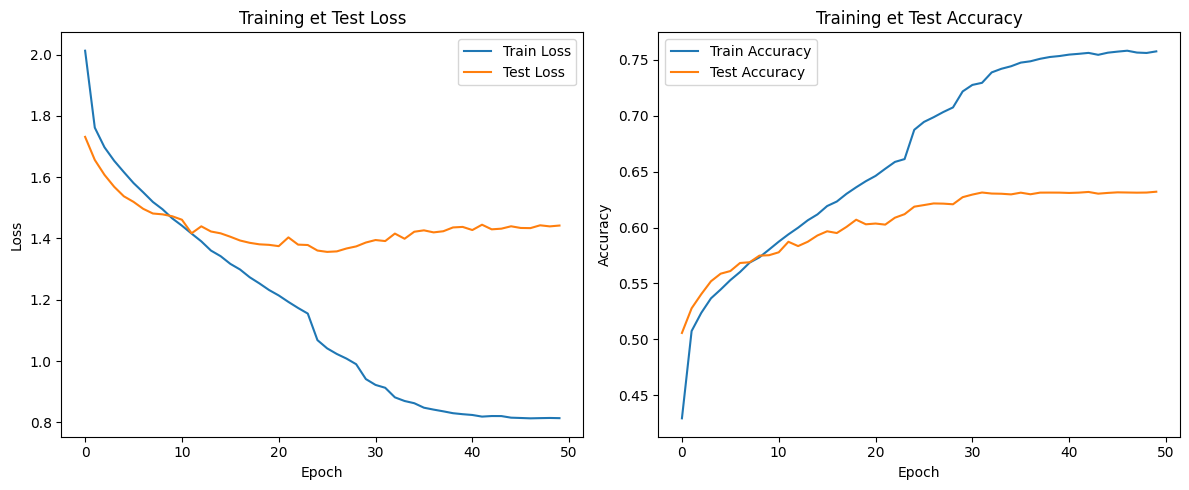

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

epoch = np.arange(1,21)

#Historique du Loss

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(liste_train_loss, label="Train Loss")
plt.plot(liste_val_loss, label="Test Loss")
plt.title("Training et Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Historique de l'accuracy
plt.subplot(1, 2, 2)
plt.plot(liste_train_acc, label="Train Accuracy")
plt.plot(liste_val_acc, label="Test Accuracy")
plt.title("Training et Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Matrice de confusion

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Chargement du meilleur modèle
model.load_state_dict(torch.load("./best_model.pt", map_location=device))
model.to(device)
model.eval()

# DataLoader test
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# Évaluation sur les données de test
test_loss = 0
correct_test = 0
total_test = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids, attention_mask)

        loss = F.cross_entropy(outputs, labels)
        test_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Moyennes
test_loss /= len(test_loader)
test_acc = correct_test / total_test

print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}\n")

# Rapport de classification
print("Rapport de classification (Test):")
print(classification_report(
    all_labels,
    all_preds,
    target_names=[labels_map[i] for i in range(len(labels_map))],
    digits=4,
    zero_division=0
))



Test Loss: 1.8241, Test Accuracy: 0.5240

Rapport de classification (Test):
                      precision    recall  f1-score   support

               music     0.5158    0.4726    0.4932      4520
              people     0.2399    0.1734    0.2013      1580
              gaming     0.5117    0.6851    0.5858      2820
      sports/actions     0.7140    0.7123    0.7132      6480
news/events/politics     0.4567    0.4058    0.4298      2740
           education     0.3214    0.3892    0.3521      1480
            tv shows     0.2741    0.2175    0.2426      1540
        movie/comedy     0.4545    0.5570    0.5005      6020
           animation     0.4602    0.4857    0.4726      2440
      vehicles/autos     0.7231    0.7541    0.7383      4880
               howto     0.5082    0.5286    0.5182      3460
              travel     0.4508    0.4760    0.4630      1500
  science/technology     0.4836    0.3612    0.4135      2780
        animals/pets     0.6432    0.5906    0.6158   

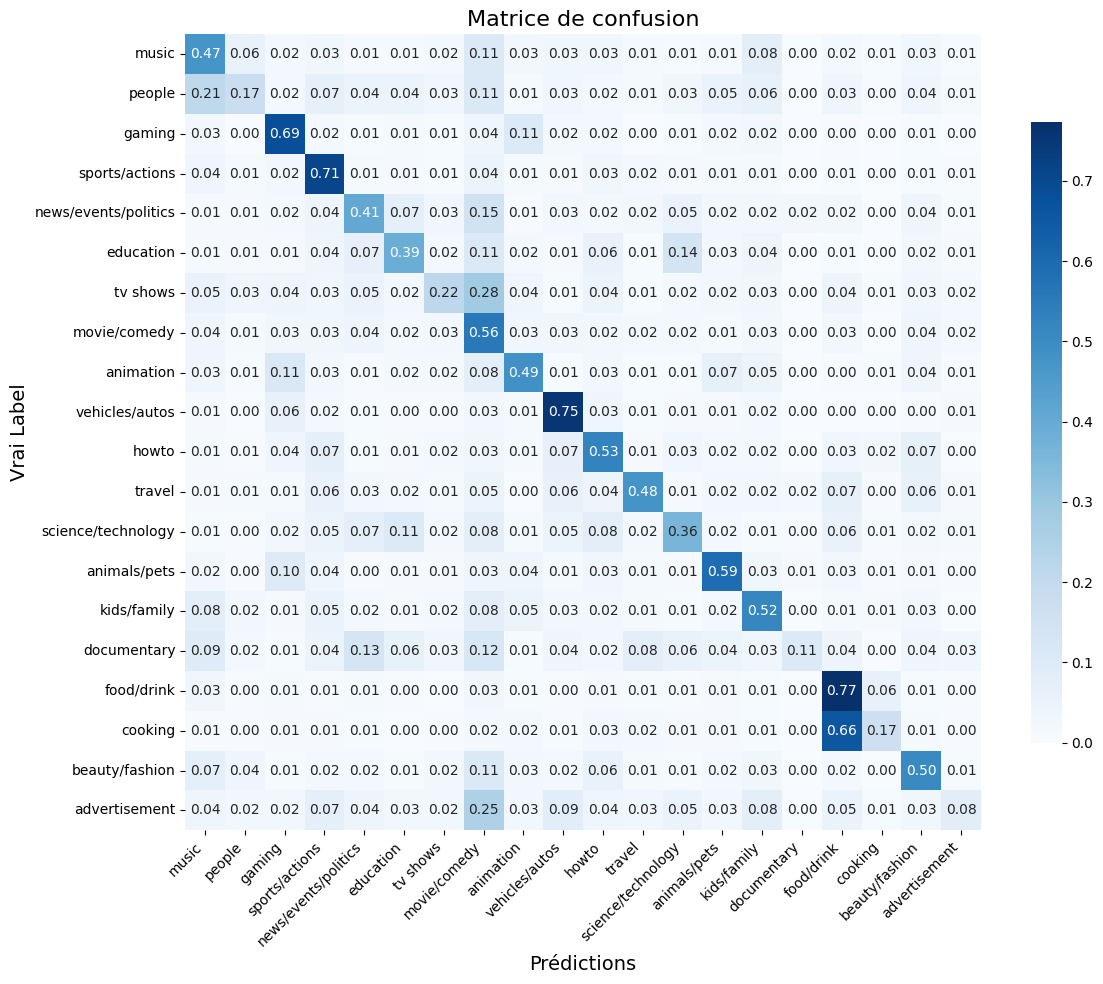

In [ ]:
"o"
# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[labels_map[i] for i in range(len(labels_map))],
    yticklabels=[labels_map[i] for i in range(len(labels_map))],
    square=True,
    cbar=True,
    cbar_kws={"shrink": 0.75}
)
plt.title("Matrice de confusion", fontsize=16)
plt.xlabel("Prédictions", fontsize=14)
plt.ylabel("Vrai Label", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# **Modèle 2**